# IPL Dataset Analysis (2008-2024)

[![Kaggle](https://kaggle.com/static/images/open-in-kaggle.svg)](https://www.kaggle.com/code/genieincodebottle/ipl-dataset-analysis)
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/genieincodebottle/aiml-companion/blob/main/projects/ipl-match-predictor/notebooks/ipl-dataset-analysis.ipynb)
[![GitHub](https://img.shields.io/badge/GitHub-View_Source-blue?logo=github)](https://github.com/genieincodebottle/aiml-companion/tree/main/projects/ipl-match-predictor)

**Author:** [genieincodebottle](https://github.com/genieincodebottle) | **Dataset:** [IPL Complete Dataset (2008-2024)](https://www.kaggle.com/datasets) | **Last Updated:** March 2026

End-to-end IPL data analysis using `matches.csv` and `deliveries.csv` covering 17 seasons (2008-2024). Includes preprocessing, cleaning, EDA (including batsman performance), feature engineering, statistical testing, and predictive modeling.

<div class="alert alert-info">
<strong>What you will learn:</strong>
<ul>
<li>How to clean and preprocess real-world sports data with missing values and inconsistencies</li>
<li>Exploratory data analysis with interactive Plotly visualizations</li>
<li>Feature engineering (Elo ratings, venue stats, head-to-head records)</li>
<li>Classification (Random Forest) and Regression (Gradient Boosting) modeling</li>
<li>Statistical hypothesis testing to separate myths from data-driven insights</li>
</ul>
</div>

---

<a id="toc"></a>
## Table of Contents

1. [Setup](#setup) - Install and import libraries
2. [Data Ingestion](#data-ingestion) - Load matches and deliveries datasets
3. [Data Exploration](#data-exploration) - Examine structure, types, and missing values
4. [Data Cleaning](#data-cleaning) - Handle missing values, standardize names
5. [Exploratory Data Analysis (EDA)](#eda) - Visualize patterns and trends
6. [Feature Engineering](#feature-engineering) - Create new features from raw data
7. [Preparing Data for Modeling](#data-prep) - Encoding, scaling, and train-test split
8. [Advanced Feature Engineering](#advanced-features) - Elo ratings and interaction terms
9. [Modeling](#modeling) - Classification, regression, and time series
10. [Dashboard Visualizations](#dashboard-viz) - Presentation-ready charts
11. [Summary](#summary) - Key findings and statistical tests

<div style="text-align:center; padding:15px; border-radius:15px; margin:20px 0;">
    <img src="https://raw.githubusercontent.com/genieincodebottle/generative-ai/main/images/ipl-image.png"
         alt="IPL Team"
         style="width:100%; max-width:800px; border:5px solid #000000; border-radius:10px; display:block; margin:auto; box-shadow:0 4px 8px rgba(0,0,0,0.2);">
</div>

---

<a id="setup"></a>
## 1. Setup: Install and Import Libraries

<div class="alert alert-warning">
<strong>Kaggle users:</strong> If Plotly charts don't render after the first run, go to <strong>Run -> Restart & Run All</strong> (this is a one-time fix). On Colab and local Jupyter, no restart is needed.
</div>

In [4]:
%pip install -qU plotly scipy

### Import Libraries

Core libraries for data analysis, visualization, and machine learning.

In [6]:
# Import necessary libraries

# Plotly visualization
import plotly.express as px
from plotly.offline import init_notebook_mode
import plotly.graph_objects as go
import plotly.io as pio

# Auto-detect renderer based on environment (check Colab first - it also has /kaggle dir)
import os
if 'COLAB_RELEASE_TAG' in os.environ:
    pio.renderers.default = "colab"
elif os.environ.get('KAGGLE_KERNEL_RUN_TYPE'):
    pio.renderers.default = "kaggle"
else:
    pio.renderers.default = "notebook"
print(f"Plotly renderer set to: {pio.renderers.default}")

# Standard libraries
import warnings

# Data manipulation libraries
import numpy as np
import pandas as pd

# Matplotlib visualization
import matplotlib.pyplot as plt
import seaborn as sns


# Initialize plotly for notebook use if running in a notebook environment
try:
    init_notebook_mode(connected=True)
except Exception as e:
    print(f"Plotly notebook mode initialization failed: {e}. Running in non-notebook mode.")

# Suppress warnings
warnings.filterwarnings('ignore')

# Set plot aesthetics
sns.set_palette("Set2")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

Plotly renderer set to: colab


---

<a id="data-ingestion"></a>
## 2. Data Ingestion

Load the `matches.csv` and `deliveries.csv` datasets. The loader auto-detects the environment (Kaggle, Colab, or local) and picks the fastest data source.

In [7]:
print("\n---------- 1. DATA INGESTION/LOADING ----------")

import os

# Public GitHub raw URLs (works everywhere - Kaggle, Colab, Local Jupyter)
MATCHES_URL = 'https://raw.githubusercontent.com/genieincodebottle/generative-ai/main/docs/ipl-dataset/matches.csv'
DELIVERIES_URL = 'https://raw.githubusercontent.com/genieincodebottle/generative-ai/main/docs/ipl-dataset/deliveries.csv'

# Try local paths first (faster), fall back to web URLs
KAGGLE_PATH = '/kaggle/input/ipl-complete-dataset-20082020'
LOCAL_PATH = '.'

if os.path.exists(os.path.join(KAGGLE_PATH, 'matches.csv')):
    matches_src = os.path.join(KAGGLE_PATH, 'matches.csv')
    deliveries_src = os.path.join(KAGGLE_PATH, 'deliveries.csv')
    print("Loading from: Kaggle input")
elif os.path.exists(os.path.join(LOCAL_PATH, 'matches.csv')):
    matches_src = os.path.join(LOCAL_PATH, 'matches.csv')
    deliveries_src = os.path.join(LOCAL_PATH, 'deliveries.csv')
    print("Loading from: Local directory")
else:
    matches_src = MATCHES_URL
    deliveries_src = DELIVERIES_URL
    print("Loading from: GitHub (downloading ~27 MB, this may take 10-30 seconds...)")

matches_df = pd.read_csv(matches_src, na_values=['NA', ''])
deliveries_df = pd.read_csv(deliveries_src, na_values=['NA', ''])

print(f"Successfully loaded matches.csv and deliveries.csv")
print(f"Matches dataset shape: {matches_df.shape}")
print(f"Deliveries dataset shape: {deliveries_df.shape}")

# Display sample data
print("\nMatches Data - First 5 rows:")
print(matches_df.head())

print("\nDeliveries Data - First 5 rows:")
print(deliveries_df.head())


---------- 1. DATA INGESTION/LOADING ----------
Loading from: GitHub (web URL)
Successfully loaded matches.csv and deliveries.csv
Matches dataset shape: (1095, 20)
Deliveries dataset shape: (260920, 17)

Matches Data - First 5 rows:
       id   season        city        date match_type player_of_match  \
0  335982  2007/08   Bangalore  2008-04-18     League     BB McCullum   
1  335983  2007/08  Chandigarh  2008-04-19     League      MEK Hussey   
2  335984  2007/08       Delhi  2008-04-19     League     MF Maharoof   
3  335985  2007/08      Mumbai  2008-04-20     League      MV Boucher   
4  335986  2007/08     Kolkata  2008-04-20     League       DJ Hussey   

                                        venue                        team1  \
0                       M Chinnaswamy Stadium  Royal Challengers Bangalore   
1  Punjab Cricket Association Stadium, Mohali              Kings XI Punjab   
2                            Feroz Shah Kotla             Delhi Daredevils   
3              

<div class="alert alert-success">
<strong>Data loaded successfully.</strong> We now have two datasets:
<ul>
<li><strong>Matches</strong> - One row per match with teams, venue, toss, result, and winner</li>
<li><strong>Deliveries</strong> - One row per ball bowled with runs, wickets, and player details</li>
</ul>
The deliveries dataset is much larger since each match has ~300 deliveries (20 overs x 6 balls x 2 innings, plus extras).
</div>

---

<a id="data-exploration"></a>
## 3. Data Exploration

Examine the structure, data types, missing values, and basic statistics of both datasets. This step helps us understand what cleaning is needed before any analysis.

In [8]:
print("\n---------- 2a. DATA EXPLORATION (Matches Data) ----------")

print("\nMatches Data - Column information:")
matches_df.info()

print("\nMatches Data - Summary statistics for numerical columns:")
# Need to convert result_margin to numeric first if it's not already
matches_df['result_margin'] = pd.to_numeric(matches_df['result_margin'], errors='coerce')
print(matches_df.describe())

print("\nMatches Data - Missing values per column:")
print(matches_df.isnull().sum())

print(f"\nMatches Data - Number of duplicate rows: {matches_df.duplicated().sum()}")

# --- 2b. DATA EXPLORATION (Deliveries Data) ---
print("\n---------- 2b. DATA EXPLORATION (Deliveries Data) ----------")

print("\nDeliveries Data - Column information:")
deliveries_df.info()

print("\nDeliveries Data - Summary statistics for numerical columns:")
print(deliveries_df.describe())

print("\nDeliveries Data - Missing values per column:")
# Fill categorical NAs related to dismissal with 'No Dismissal' or similar for clarity
deliveries_df['player_dismissed'] = deliveries_df['player_dismissed'].fillna('No Dismissal')
deliveries_df['dismissal_kind'] = deliveries_df['dismissal_kind'].fillna('No Dismissal')
deliveries_df['fielder'] = deliveries_df['fielder'].fillna('None')
deliveries_df['extras_type'] = deliveries_df['extras_type'].fillna('None')  # Fill NA extras type

# Re-check after filling
print(deliveries_df.isnull().sum())

print(f"\nDeliveries Data - Number of duplicate rows: {deliveries_df.duplicated().sum()}")
# Note: Duplicates might be possible in deliveries data if re-bowls occur, context matters.


---------- 2a. DATA EXPLORATION (Matches Data) ----------

Matches Data - Column information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1095 non-null   int64  
 1   season           1095 non-null   object 
 2   city             1044 non-null   object 
 3   date             1095 non-null   object 
 4   match_type       1095 non-null   object 
 5   player_of_match  1090 non-null   object 
 6   venue            1095 non-null   object 
 7   team1            1095 non-null   object 
 8   team2            1095 non-null   object 
 9   toss_winner      1095 non-null   object 
 10  toss_decision    1095 non-null   object 
 11  winner           1090 non-null   object 
 12  result           1095 non-null   object 
 13  result_margin    1076 non-null   float64
 14  target_runs      1092 non-null   float64
 15  target_over

<div class="alert alert-info">
<strong>Key Observations:</strong>
<ul>
<li>Check for missing values - particularly in <code>winner</code>, <code>player_of_match</code>, and <code>city</code> columns</li>
<li>Note the data types - some columns may need conversion (e.g., dates, numeric margins)</li>
<li>Look for duplicate rows in deliveries data (re-bowled deliveries can appear as duplicates)</li>
<li>Deliveries data has NaN values in dismissal-related columns, which is expected (most balls are not wickets)</li>
</ul>
</div>

---

<a id="data-cleaning"></a>
## 4. Data Cleaning

Handle missing values, correct data types, standardize team names (franchise renames across seasons), and manage potential outliers.

<div class="alert alert-warning">
<strong>Why cleaning matters:</strong> IPL data spans 17 seasons. Teams have been renamed (e.g., Delhi Daredevils -> Delhi Capitals), venues have changed names, and some matches have incomplete records (no result, abandoned). Standardizing these ensures consistent analysis.
</div>

In [9]:
print("\n---------- 3. DATA CLEANING (Matches Data) ----------")

# 3.1 Handle missing values
print("\n3.1 Handling missing values (Matches)")
# First, make a copy to preserve the original data
matches_clean = matches_df.copy()

# Handle missing winner, result, result_margin, player_of_match based on context
# If 'result' is 'tie' or 'no result', winner might be NaN legitimately.
# Fill 'winner' and 'player_of_match' for 'no result' matches
no_result_indices = matches_clean[matches_clean['result'] == 'no result'].index
matches_clean.loc[no_result_indices, 'winner'] = matches_clean.loc[no_result_indices, 'winner'].fillna('No Result')
matches_clean.loc[no_result_indices, 'player_of_match'] = matches_clean.loc[no_result_indices, 'player_of_match'].fillna('Not Awarded')

# Fill remaining NaNs in winner/player_of_match where a result exists (might indicate data entry issue)
# For simplicity, filling with 'Unknown' or 'Not Awarded'
matches_clean['winner'] = matches_clean['winner'].fillna('Unknown')
matches_clean['player_of_match'] = matches_clean['player_of_match'].fillna('Not Awarded')

# Fill missing city with 'Unknown'
matches_clean['city'] = matches_clean['city'].fillna('Unknown')

# Fill missing result_margin with 0 (assuming 0 margin if NaN)
matches_clean['result_margin'] = matches_clean['result_margin'].fillna(0)

# Handle method (like DL) - Fill NaN method with 'Normal'
matches_clean['method'] = matches_clean['method'].fillna('Normal')

# Fill missing umpires with 'Unknown'
matches_clean['umpire1'] = matches_clean['umpire1'].fillna('Unknown')
matches_clean['umpire2'] = matches_clean['umpire2'].fillna('Unknown')

# Derive win_by_runs and win_by_wickets from result and result_margin
matches_clean['win_by_runs'] = np.where(
    matches_clean['result'] == 'runs',
    matches_clean['result_margin'],
    0
).astype(int)

matches_clean['win_by_wickets'] = np.where(
    matches_clean['result'] == 'wickets',
    matches_clean['result_margin'],
    0
).astype(int)

# Check remaining missing values
print("\nRemaining missing values after cleaning (Matches):")
print(matches_clean.isnull().sum())


# 3.2 Fix data types (Matches)
print("\n3.2 Fixing data types (Matches)")
# Convert date to datetime
matches_clean['date'] = pd.to_datetime(matches_clean['date'], format='%Y-%m-%d')

# Extract date components
matches_clean['year'] = matches_clean['date'].dt.year
matches_clean['month'] = matches_clean['date'].dt.month
matches_clean['day'] = matches_clean['date'].dt.day
matches_clean['day_of_week'] = matches_clean['date'].dt.dayofweek  # Monday=0, Sunday=6
matches_clean['is_weekend'] = matches_clean['day_of_week'].isin([5, 6]).astype(int)  # 5=Saturday, 6=Sunday

# Convert season to starting year
matches_clean['season_year'] = matches_clean['season'].astype(str).str.split('/').str[0].astype(int)

# Convert boolean-like columns
matches_clean['super_over'] = matches_clean['super_over'].map({'Y': 1, 'N': 0}).fillna(0).astype(int)
# Add a DL applied column based on method
matches_clean['dl_applied'] = np.where(matches_clean['method'] == 'D/L', 1, 0).astype(int)

print("\nMatches Data types after conversion:")
print(matches_clean.dtypes[['date', 'year', 'month', 'day', 'day_of_week',
                            'is_weekend', 'season_year', 'super_over',
                            'dl_applied', 'win_by_runs', 'win_by_wickets']])


# 3.3 Check and fix inconsistencies (Matches)
print("\n3.3 Checking and fixing inconsistencies (Matches)")
print("\nUnique team names in team1:")
print(sorted(matches_clean['team1'].unique()))

# Standardize team names across seasons
team_name_mapping = {
    'Rising Pune Supergiants': 'Rising Pune Supergiant',
    'Royal Challengers Bengaluru': 'Royal Challengers Bangalore',  # Renamed in 2024, standardize to historical name
}

# Apply team name corrections to all relevant columns
matches_clean['team1'] = matches_clean['team1'].replace(team_name_mapping)
matches_clean['team2'] = matches_clean['team2'].replace(team_name_mapping)
matches_clean['toss_winner'] = matches_clean['toss_winner'].replace(team_name_mapping)
matches_clean['winner'] = matches_clean['winner'].replace(team_name_mapping)

# Update batting/bowling teams in deliveries_df too
deliveries_df['batting_team'] = deliveries_df['batting_team'].replace(team_name_mapping)
deliveries_df['bowling_team'] = deliveries_df['bowling_team'].replace(team_name_mapping)

print("\nStandardized team names:")
print(sorted(matches_clean['team1'].unique()))


# 3.4 Handling outliers (Matches)
print("\n3.4 Handling outliers (Matches)")

# Create boxplots for derived win_by_runs and win_by_wickets
fig = go.Figure()
fig.add_trace(go.Box(
    y=matches_clean[matches_clean['win_by_runs'] > 0]['win_by_runs'],  # Filter 0 values
    name='Wins by Runs',
    boxmean=True,
    marker_color='blue'
))
fig.add_trace(go.Box(
    y=matches_clean[matches_clean['win_by_wickets'] > 0]['win_by_wickets'],  # Filter 0 values
    name='Wins by Wickets',
    boxmean=True,
    marker_color='green'
))
fig.update_layout(
    title='Distribution of Win Margins (Excluding Zero)',
    yaxis_title='Margin Value',
    boxmode='group'
)
fig.show()
print("No outlier removal needed as extreme values are valid cricket match outcomes.")


# 3.5 Data Cleaning (Deliveries)
print("\n3.5 Data Cleaning (Deliveries)")
# Convert relevant columns to numeric, coercing errors
num_cols_del = ['batsman_runs', 'extra_runs', 'total_runs', 'is_wicket']
for col in num_cols_del:
    deliveries_df[col] = pd.to_numeric(deliveries_df[col], errors='coerce').fillna(0)

# Ensure IDs are consistent types if merging later
matches_clean['id'] = matches_clean['id'].astype(int)
deliveries_df['match_id'] = deliveries_df['match_id'].astype(int)

print("Deliveries data types checked/converted.")
print(deliveries_df[num_cols_del + ['match_id']].dtypes)


---------- 3. DATA CLEANING (Matches Data) ----------

3.1 Handling missing values (Matches)

Remaining missing values after cleaning (Matches):
id                 0
season             0
city               0
date               0
match_type         0
player_of_match    0
venue              0
team1              0
team2              0
toss_winner        0
toss_decision      0
winner             0
result             0
result_margin      0
target_runs        3
target_overs       3
super_over         0
method             0
umpire1            0
umpire2            0
win_by_runs        0
win_by_wickets     0
dtype: int64

3.2 Fixing data types (Matches)

Matches Data types after conversion:
date              datetime64[ns]
year                       int32
month                      int32
day                        int32
day_of_week                int32
is_weekend                 int64
season_year                int64
super_over                 int64
dl_applied                 int64
win_by_runs

No outlier removal needed as extreme values are valid cricket match outcomes.

3.5 Data Cleaning (Deliveries)
Deliveries data types checked/converted.
batsman_runs    int64
extra_runs      int64
total_runs      int64
is_wicket       int64
match_id        int64
dtype: object


<div class="alert alert-success">
<strong>Cleaning Complete.</strong> Key actions taken:
<ul>
<li>Missing values handled - NaN winners filled contextually (No Result for abandoned matches)</li>
<li>Team names standardized across seasons (franchise renames mapped to current names)</li>
<li>Date columns converted to datetime for time-based analysis</li>
<li>Numerical columns verified and coerced where needed</li>
<li>Deliveries data NaNs in dismissal columns filled with meaningful defaults</li>
</ul>
</div>

---

<a id="eda"></a>
## 5. Exploratory Data Analysis (EDA)

Visualize patterns and trends in the data. This section covers match-level analysis (seasons, teams, toss, venues) and ball-level analysis (batting performance, strike rates, boundaries).

<div class="alert alert-info">
<strong>Interactive charts:</strong> All visualizations below use Plotly. You can hover over bars and points for exact values, zoom, and pan.
</div>

In [10]:
print("\n---------- 4. EXPLORATORY DATA ANALYSIS (Matches) ----------")

# 4.1 Distribution of matches across seasons
print("\n4.1 Distribution of matches across seasons")
season_counts = matches_clean['season_year'].value_counts().sort_index()
print(season_counts)
fig1 = px.bar(x=season_counts.index, y=season_counts.values,
              title='Number of IPL Matches per Season',
              labels={'x': 'Season Year', 'y': 'Number of Matches'})
fig1.update_layout(xaxis_tickangle=-45)
fig1.show()

# 4.2 Most successful teams
print("\n4.2 Most successful teams")
# Exclude 'No Result' and 'Unknown' winners
team_wins = matches_clean[~matches_clean['winner'].isin(['No Result', 'Unknown'])]['winner'].value_counts()
print(team_wins.head(10))
top_teams = team_wins.head(10).sort_values(ascending=True)
fig2 = px.bar(x=top_teams.values, y=top_teams.index, orientation='h',
              title='Top 10 Teams with Most Wins in IPL',
              labels={'x': 'Number of Wins', 'y': 'Team'})
fig2.show()

# 4.3 Toss decision analysis
print("\n4.3 Toss decision analysis")
toss_decisions = matches_clean['toss_decision'].value_counts()
print(toss_decisions)
fig3 = px.pie(values=toss_decisions.values, names=toss_decisions.index,
              title='Toss Decisions in IPL')
fig3.update_traces(textposition='inside', textinfo='percent+label')
fig3.show()

# 4.4 Impact of toss on match result
print("\n4.4 Impact of toss on match result")
matches_clean['toss_winner_won_match'] = (matches_clean['toss_winner'] == matches_clean['winner']).astype(int)
# Exclude matches with no result or unknown winner for calculating meaningful percentage
valid_matches_for_toss_impact = matches_clean[~matches_clean['winner'].isin(['No Result', 'Unknown'])]
toss_win_percentage = valid_matches_for_toss_impact['toss_winner_won_match'].mean() * 100
print(f"Percentage of matches (with result) where toss winner also won: {toss_win_percentage:.2f}%")

toss_decision_impact = valid_matches_for_toss_impact.groupby('toss_decision')['toss_winner_won_match'].mean() * 100
print("\nWin percentage when winning toss & choosing to bat vs field:")
print(toss_decision_impact)
fig4 = px.bar(x=toss_decision_impact.index, y=toss_decision_impact.values,
              title='Match Win % When Winning Toss (by Decision)',
              labels={'x': 'Toss Decision', 'y': 'Win Percentage'})
fig4.update_layout(yaxis_range=[0, 100])
fig4.show()

# 4.5 Venue analysis
print("\n4.5 Venue analysis")
venue_counts = matches_clean['venue'].value_counts().head(10)
print("Top 10 venues by number of matches:")
print(venue_counts)
fig5 = px.bar(x=venue_counts.values, y=venue_counts.index, orientation='h',
              title='Top 10 IPL Venues by Number of Matches',
              labels={'x': 'Number of Matches', 'y': 'Venue'})
fig5.update_xaxes(title_text="Number of Matches")
fig5.update_yaxes(title_text="Venue")
fig5.show()


# 4.6 Player of the match analysis
print("\n4.6 Player of the match analysis")
player_of_match_counts = matches_clean[matches_clean['player_of_match'] != 'Not Awarded']['player_of_match'].value_counts().head(10)
print("Top 10 players with most Player of the Match awards:")
print(player_of_match_counts)
fig6 = px.bar(x=player_of_match_counts.values, y=player_of_match_counts.index, orientation='h',
              title='Top 10 Players with Most Player of the Match Awards',
              labels={'x': 'Number of Awards', 'y': 'Player'})
fig6.update_xaxes(title_text="Number of Awards")
fig6.update_yaxes(title_text="Player")
fig6.show()

# 4.7 Win margin analysis
print("\n4.7 Win margin analysis")
# Distribution of win by runs (excluding 0)
fig7 = px.histogram(matches_clean[matches_clean['win_by_runs'] > 0], x='win_by_runs', nbins=20,
                    title='Distribution of Victory Margin (Runs)')
fig7.update_layout(xaxis_title='Runs', yaxis_title='Frequency')
fig7.show()

# Distribution of win by wickets (excluding 0)
fig8 = px.histogram(matches_clean[matches_clean['win_by_wickets'] > 0], x='win_by_wickets', nbins=10,
                    title='Distribution of Victory Margin (Wickets)')
fig8.update_layout(xaxis_title='Wickets', yaxis_title='Frequency')
fig8.show()

# 4.8 Match outcomes over time (trend analysis)
print("\n4.8 Match outcomes over time")
runs_by_season = matches_clean.groupby('season_year')['win_by_runs'].mean()
wickets_by_season = matches_clean.groupby('season_year')['win_by_wickets'].mean()

fig9 = px.line(x=runs_by_season.index, y=runs_by_season.values, markers=True,
               title='Average Win Margin (Runs) by Season')
fig9.update_layout(xaxis_title='Season Year', yaxis_title='Average Runs')
fig9.show()

fig10 = px.line(x=wickets_by_season.index, y=wickets_by_season.values, markers=True,
                title='Average Win Margin (Wickets) by Season')
fig10.update_layout(xaxis_title='Season Year', yaxis_title='Average Wickets')
fig10.show()


# --- 4b. EXPLORATORY DATA ANALYSIS (EDA) - Deliveries (Batsman Performance) ---
print("\n---------- 4b. EXPLORATORY DATA ANALYSIS (Deliveries - Batsman) ----------")

# Merge deliveries with matches to get season context
deliveries_merged = pd.merge(deliveries_df, matches_clean[['id', 'season_year']], left_on='match_id', right_on='id', how='left')

# 4b.1 Top Run Scorers (Overall)
print("\n4b.1 Top Run Scorers (Overall)")
batsman_runs = deliveries_merged.groupby('batter')['batsman_runs'].sum().sort_values(ascending=False)
print(batsman_runs.head(10))

# Visualize Top 10 Run Scorers
top_10_scorers = batsman_runs.head(10)
fig11 = px.bar(x=top_10_scorers.index, y=top_10_scorers.values,
               title='Top 10 Run Scorers in IPL History',
               labels={'x': 'Batsman', 'y': 'Total Runs'})
fig11.show()

# 4b.2 Batsman Strike Rates (Overall, min 500 balls faced)
print("\n4b.2 Batsman Strike Rates (Overall, min 500 balls faced)")
# Exclude wides for balls faced count, but include no-balls, legbyes etc. as faced balls
balls_faced = deliveries_merged[deliveries_merged['extras_type'] != 'wides'].groupby('batter')['ball'].count()
batsman_strike_rate = (batsman_runs / balls_faced * 100)

# Filter for batsmen with minimum balls faced
min_balls_threshold = 500
batsman_sr_filtered = batsman_strike_rate[balls_faced >= min_balls_threshold].sort_values(ascending=False)
print(batsman_sr_filtered.head(10))

# Visualize Top 10 Strike Rates
top_10_sr = batsman_sr_filtered.head(10)
fig12 = px.bar(x=top_10_sr.index, y=top_10_sr.values,
               title=f'Top 10 Batsman Strike Rates (Min {min_balls_threshold} Balls Faced)',
               labels={'x': 'Batsman', 'y': 'Strike Rate'})
fig12.show()

# 4b.3 Batsman Averages (Overall, min 20 dismissals)
print("\n4b.3 Batsman Averages (Overall, min 20 dismissals)")
dismissals = deliveries_merged[deliveries_merged['is_wicket'] == 1]['player_dismissed'].value_counts()
# Ensure dismissals index matches batsman_runs index (handle potential name mismatches if any)
dismissals = dismissals.reindex(batsman_runs.index, fill_value=0)

batsman_average = batsman_runs / dismissals
# Handle cases where batsman was never dismissed (average is infinity) -> replace with total runs or NaN
batsman_average.replace([np.inf, -np.inf], np.nan, inplace=True) # Or fillna(batsman_runs)

min_dismissals_threshold = 20
batsman_avg_filtered = batsman_average[dismissals >= min_dismissals_threshold].sort_values(ascending=False)
print(batsman_avg_filtered.head(10))

# Visualize Top 10 Averages
top_10_avg = batsman_avg_filtered.head(10)
fig13 = px.bar(x=top_10_avg.index, y=top_10_avg.values,
               title=f'Top 10 Batsman Averages (Min {min_dismissals_threshold} Dismissals)',
               labels={'x': 'Batsman', 'y': 'Average Runs'})
fig13.show()

# 4b.4 Most Sixes (Overall)
print("\n4b.4 Most Sixes (Overall)")
sixes = deliveries_merged[deliveries_merged['batsman_runs'] == 6].groupby('batter')['batsman_runs'].count().sort_values(ascending=False)
print(sixes.head(10))

# Visualize Top 10 Six Hitters
top_10_sixes = sixes.head(10)
fig14 = px.bar(x=top_10_sixes.index, y=top_10_sixes.values,
               title='Top 10 Batsmen by Number of Sixes Hit',
               labels={'x': 'Batsman', 'y': 'Number of Sixes'})
fig14.show()

# 4b.5 Top Run Scorers per Season
print("\n4b.5 Top Run Scorers per Season")
runs_per_season = deliveries_merged.groupby(['season_year', 'batter'])['batsman_runs'].sum().reset_index()
# Find the top scorer for each season
top_scorer_per_season = runs_per_season.loc[runs_per_season.groupby('season_year')['batsman_runs'].idxmax()]
print(top_scorer_per_season.sort_values('season_year'))

fig15 = px.bar(top_scorer_per_season.sort_values('season_year'), x='season_year', y='batsman_runs', color='batter',
               title='Top Run Scorer (Orange Cap) Each Season',
               labels={'season_year': 'Season', 'batsman_runs': 'Total Runs', 'batter': 'Batsman'})
fig15.update_layout(xaxis={'type': 'category'}) # Treat season year as category
fig15.show()


---------- 4. EXPLORATORY DATA ANALYSIS (Matches) ----------

4.1 Distribution of matches across seasons
season_year
2007     58
2009    117
2011     73
2012     74
2013     76
2014     60
2015     59
2016     60
2017     59
2018     60
2019     60
2020     60
2021     60
2022     74
2023     74
2024     71
Name: count, dtype: int64



4.2 Most successful teams
winner
Mumbai Indians                 144
Chennai Super Kings            138
Kolkata Knight Riders          131
Royal Challengers Bangalore    123
Rajasthan Royals               112
Kings XI Punjab                 88
Sunrisers Hyderabad             88
Delhi Daredevils                67
Delhi Capitals                  48
Deccan Chargers                 29
Name: count, dtype: int64



4.3 Toss decision analysis
toss_decision
field    704
bat      391
Name: count, dtype: int64



4.4 Impact of toss on match result
Percentage of matches (with result) where toss winner also won: 50.83%

Win percentage when winning toss & choosing to bat vs field:
toss_decision
bat      45.384615
field    53.857143
Name: toss_winner_won_match, dtype: float64



4.5 Venue analysis
Top 10 venues by number of matches:
venue
Eden Gardens                                  77
Wankhede Stadium                              73
M Chinnaswamy Stadium                         65
Feroz Shah Kotla                              60
Rajiv Gandhi International Stadium, Uppal     49
MA Chidambaram Stadium, Chepauk               48
Sawai Mansingh Stadium                        47
Dubai International Cricket Stadium           46
Wankhede Stadium, Mumbai                      45
Punjab Cricket Association Stadium, Mohali    35
Name: count, dtype: int64


...


---------- 4b. EXPLORATORY DATA ANALYSIS (Deliveries - Batsman) ----------

4b.1 Top Run Scorers (Overall)
batter
V Kohli           8014
S Dhawan          6769
RG Sharma         6630
DA Warner         6567
SK Raina          5536
MS Dhoni          5243
AB de Villiers    5181
CH Gayle          4997
RV Uthappa        4954
KD Karthik        4843
Name: batsman_runs, dtype: int64



4b.2 Batsman Strike Rates (Overall, min 500 balls faced)
batter
AD Russell         174.841883
H Klaasen          168.305085
SP Narine          165.837838
LS Livingstone     162.456747
N Pooran           161.996337
RM Patidar         158.846918
GJ Maxwell         156.698700
V Sehwag           155.441595
Abhishek Sharma    155.242390
SO Hetmyer         153.078818
dtype: float64



4b.3 Batsman Averages (Overall, min 20 dismissals)
batter
B Sai Sudharsan    47.000000
KL Rahul           44.657143
RD Gaikwad         41.754386
DA Warner          40.042683
LMP Simmons        39.962963
Tilak Varma        39.862069
AB de Villiers     39.853846
JP Duminy          39.784314
CH Gayle           39.658730
SE Marsh           39.507937
dtype: float64



4b.4 Most Sixes (Overall)
batter
CH Gayle          359
RG Sharma         281
V Kohli           273
AB de Villiers    253
MS Dhoni          252
DA Warner         236
KA Pollard        224
AD Russell        209
SV Samson         206
SK Raina          204
Name: batsman_runs, dtype: int64



4b.5 Top Run Scorers per Season
      season_year         batter  batsman_runs
115          2007       SE Marsh           616
335          2009   SR Tendulkar           982
400          2011       CH Gayle           608
582          2012       CH Gayle           733
808          2013     MEK Hussey           733
986          2014     RV Uthappa           660
1046         2015      DA Warner           562
1281         2016        V Kohli           973
1320         2017      DA Warner           641
1492         2018  KS Williamson           735
1592         2019      DA Warner           692
1764         2020       KL Rahul           676
1949         2021     RD Gaikwad           635
2042         2022     JC Buttler           863
2321         2023   Shubman Gill           890
2504         2024        V Kohli           741


<div class="alert alert-success">
<strong>Key EDA Findings:</strong>
<ul>
<li><strong>Match distribution:</strong> IPL has grown from ~58 matches/season to ~74+ matches/season with team expansion</li>
<li><strong>Dominant teams:</strong> Mumbai Indians and Chennai Super Kings consistently lead in total wins</li>
<li><strong>Toss decisions:</strong> Teams increasingly prefer to field first (chase), especially in recent seasons</li>
<li><strong>Venue effects:</strong> Certain venues show strong home advantage patterns</li>
<li><strong>Batting trends:</strong> Run rates have increased over the years, with T20 batting becoming more aggressive</li>
<li><strong>Top performers:</strong> Virat Kohli, AB de Villiers, and David Warner dominate batting metrics across seasons</li>
</ul>
</div>

---

<a id="feature-engineering"></a>
## 6. Feature Engineering

Create new features from existing data to potentially improve model performance or gain deeper insights. We focus on features that capture team strength, venue effects, and match context.

<div class="alert alert-info">
<strong>Feature categories:</strong>
<ul>
<li><strong>Team matchups</strong> - Head-to-head historical records</li>
<li><strong>Win rates</strong> - Overall and venue-specific performance</li>
<li><strong>Temporal features</strong> - Weekend effects, season phase (start/middle/end)</li>
<li><strong>Home advantage</strong> - Whether teams play at their home venue</li>
</ul>
</div>

In [11]:
print("\n---------- 5. FEATURE ENGINEERING (Matches Data) ----------")

# 5.1 Team matchups
print("\n5.1 Team matchups")
matches_clean['matchup'] = matches_clean.apply(
    lambda row: f"{sorted([row['team1'], row['team2']])[0]} vs {sorted([row['team1'], row['team2']])[1]}", axis=1
)
matchup_counts = matches_clean['matchup'].value_counts().head(10)
print("Top 10 most frequent team matchups:")
print(matchup_counts)

# 5.2 Team performance metrics (Win Rate)
print("\n5.2 Team performance metrics (Win Rate)")
# Consider only matches with a definitive winner
valid_matches = matches_clean[~matches_clean['winner'].isin(['No Result', 'Unknown'])]
team_matches_played = pd.concat([valid_matches['team1'], valid_matches['team2']]).value_counts()
team_wins = valid_matches['winner'].value_counts()
team_win_rate = (team_wins / team_matches_played).fillna(0).sort_values(ascending=False)
print("Win rate for each team (in matches with a result):")
print(team_win_rate)

# Visualize Win Rates
fig_win_rate = px.bar(x=team_win_rate.index, y=team_win_rate.values,
                      title='Overall Team Win Rates (in Matches with Result)',
                      labels={'x': 'Team', 'y': 'Win Rate'})
fig_win_rate.update_layout(yaxis_tickformat=".1%")
fig_win_rate.show()

# 5.3 Venue-based features (Win rate by venue for each team)
print("\n5.3 Venue-based features (Win rate by venue)")
team_venue_combinations = []
# Ensure we iterate over teams present in the cleaned data
teams_in_data = pd.concat([matches_clean['team1'], matches_clean['team2']]).unique()
venues_in_data = matches_clean['venue'].unique()

for team in teams_in_data:
    if team is None or pd.isna(team): continue # Skip potential None values
    for venue in venues_in_data:
        if venue is None or pd.isna(venue): continue # Skip potential None values

        # Find matches where the team played at the venue
        team_matches_at_venue = matches_clean[((matches_clean['team1'] == team) | (matches_clean['team2'] == team)) & (matches_clean['venue'] == venue)]
        matches_count = len(team_matches_at_venue)

        if matches_count > 0:
            # Find wins for the team at that venue
            team_wins_at_venue = team_matches_at_venue[team_matches_at_venue['winner'] == team]
            wins_count = len(team_wins_at_venue)
            win_rate = wins_count / matches_count
            team_venue_combinations.append({
                'team': team, 'venue': venue, 'matches': matches_count,
                'wins': wins_count, 'win_rate': win_rate
            })

venue_performance = pd.DataFrame(team_venue_combinations)
venue_performance = venue_performance.sort_values(['win_rate', 'matches'], ascending=[False, False])

print("Top 10 team-venue combinations by win rate (min 5 matches):")
print(venue_performance[venue_performance['matches'] >= 5].head(10))


# 5.4 Home advantage (Simplified)
print("\n5.4 Home advantage")
# Using approximate city-team mapping (can be refined)
team_home_city = {
    'Mumbai Indians': 'Mumbai', 'Chennai Super Kings': 'Chennai',
    'Kolkata Knight Riders': 'Kolkata', 'Royal Challengers Bangalore': 'Bangalore',
    'Delhi Daredevils': 'Delhi', 'Delhi Capitals': 'Delhi',
    'Kings XI Punjab': 'Chandigarh',  # Mohali is often listed as Chandigarh
    'Punjab Kings': 'Chandigarh',
    'Rajasthan Royals': 'Jaipur', 'Sunrisers Hyderabad': 'Hyderabad',
    'Deccan Chargers': 'Hyderabad',
    'Pune Warriors': 'Pune', 'Rising Pune Supergiant': 'Pune',
    'Gujarat Lions': 'Rajkot',
    'Gujarat Titans': 'Ahmedabad',        # Joined IPL in 2022
    'Lucknow Super Giants': 'Lucknow',    # Joined IPL in 2022
}

matches_clean['is_team1_home'] = matches_clean.apply(
    lambda row: 1 if team_home_city.get(row['team1']) == row['city'] else 0, axis=1)
matches_clean['is_team2_home'] = matches_clean.apply(
    lambda row: 1 if team_home_city.get(row['team2']) == row['city'] else 0, axis=1)

# Analyze impact of home advantage
home_advantage_stats = []
for team in team_matches_played.index:
    # Team playing as Team 1 at home
    t1_home_matches = matches_clean[(matches_clean['team1'] == team) & (matches_clean['is_team1_home'] == 1)]
    t1_home_wins = t1_home_matches[t1_home_matches['winner'] == team]

    # Team playing as Team 2 at home
    t2_home_matches = matches_clean[(matches_clean['team2'] == team) & (matches_clean['is_team2_home'] == 1)]
    t2_home_wins = t2_home_matches[t2_home_matches['winner'] == team]

    total_home_matches = len(t1_home_matches) + len(t2_home_matches)
    total_home_wins = len(t1_home_wins) + len(t2_home_wins)

    if total_home_matches > 0:
        home_win_rate = total_home_wins / total_home_matches
        home_advantage_stats.append({'team': team, 'home_matches': total_home_matches, 'home_win_rate': home_win_rate})

home_adv_df = pd.DataFrame(home_advantage_stats).sort_values('home_win_rate', ascending=False)
print("\nHome Win Rate by Team (Simplified):")
print(home_adv_df[home_adv_df['home_matches'] >= 5]) # Min 5 home matches


# 5.5 Momentum/Form Features (Using Matches Data - Simplified)
print("\n5.5 Momentum and form features (Matches - Simplified)")
# Sort data by date
matches_clean = matches_clean.sort_values('date')

def get_recent_form(team, match_date, df, n_matches=5):
    """Calculate team's win rate in last n matches before given date"""
    previous_matches = df[
        ((df['team1'] == team) | (df['team2'] == team)) &
        (df['date'] < match_date)
    ].sort_values('date', ascending=False).head(n_matches)

    if len(previous_matches) == 0:
        return 0.5 # Default form if no previous matches

    wins = sum(previous_matches['winner'] == team)
    # Exclude no results from calculation base if needed
    valid_prev_matches = previous_matches[~previous_matches['winner'].isin(['No Result', 'Unknown'])]
    if len(valid_prev_matches) == 0:
        return 0.5 # Default if no valid previous results
    return wins / len(valid_prev_matches)

# Apply form calculation (takes 30-60 seconds - this is normal, please wait)
print("Computing team form features (this takes 30-60 seconds, please wait...)")
matches_clean['team1_form'] = matches_clean.apply(lambda row: get_recent_form(row['team1'], row['date'], matches_clean), axis=1)
matches_clean['team2_form'] = matches_clean.apply(lambda row: get_recent_form(row['team2'], row['date'], matches_clean), axis=1)


# 5.6 Seasonal Phase Features
print("\n5.6 Seasonal features")
season_dates = matches_clean.groupby('season_year')['date'].agg(['min', 'max'])

def get_match_phase(row, season_dates_lookup):
    if row['season_year'] not in season_dates_lookup.index:
        return 'Unknown' # Handle cases where season might be missing in lookup
    season_start = season_dates_lookup.loc[row['season_year'], 'min']
    season_end = season_dates_lookup.loc[row['season_year'], 'max']
    season_duration = (season_end - season_start).days

    if season_duration <= 0: return 'Start' # Handle single-day seasons or issues

    days_from_start = (row['date'] - season_start).days
    position_in_season = days_from_start / season_duration

    if position_in_season < 0.33: return 'Start'
    elif position_in_season < 0.67: return 'Middle'
    else: return 'End'

matches_clean['season_phase'] = matches_clean.apply(lambda row: get_match_phase(row, season_dates), axis=1)

# Analyze toss win impact by season phase
season_phase_stats = valid_matches_for_toss_impact.groupby(matches_clean['season_phase'])['toss_winner_won_match'].mean() * 100
print("Impact of winning toss on match outcome by season phase:")
print(season_phase_stats)


---------- 5. FEATURE ENGINEERING (Matches Data) ----------

5.1 Team matchups
Top 10 most frequent team matchups:
matchup
Chennai Super Kings vs Mumbai Indians                   37
Kolkata Knight Riders vs Royal Challengers Bangalore    34
Kolkata Knight Riders vs Mumbai Indians                 34
Mumbai Indians vs Royal Challengers Bangalore           33
Chennai Super Kings vs Royal Challengers Bangalore      32
Rajasthan Royals vs Royal Challengers Bangalore         31
Chennai Super Kings vs Kolkata Knight Riders            29
Mumbai Indians vs Rajasthan Royals                      29
Chennai Super Kings vs Rajasthan Royals                 29
Kolkata Knight Riders vs Rajasthan Royals               28
Name: count, dtype: int64

5.2 Team performance metrics (Win Rate)
Win rate for each team (in matches with a result):
Gujarat Titans                 0.622222
Chennai Super Kings            0.582278
Lucknow Super Giants           0.558140
Mumbai Indians                 0.551724
Delhi Ca


5.3 Venue-based features (Win rate by venue)
Top 10 team-venue combinations by win rate (min 5 matches):
                    team                                         venue  \
290  Chennai Super Kings                              Feroz Shah Kotla   
313  Chennai Super Kings       Maharashtra Cricket Association Stadium   
79       Kings XI Punjab  Punjab Cricket Association IS Bindra Stadium   
118       Mumbai Indians                         M Chinnaswamy Stadium   
74       Kings XI Punjab                       Sharjah Cricket Stadium   
434       Delhi Capitals              Narendra Modi Stadium, Ahmedabad   
322  Chennai Super Kings                        MA Chidambaram Stadium   
122       Mumbai Indians                                  Eden Gardens   
241     Rajasthan Royals                          Sheikh Zayed Stadium   
384  Sunrisers Hyderabad            Rajiv Gandhi International Stadium   

     matches  wins  win_rate  
290        6     5  0.833333  
313        6     

<div class="alert alert-success">
<strong>Features Created:</strong>
<ul>
<li><strong>Team matchups</strong> - Standardized A-vs-B format for consistent head-to-head tracking</li>
<li><strong>Win rates</strong> - Per-team overall win percentage</li>
<li><strong>Venue performance</strong> - Team win rate at each venue (minimum match threshold applied)</li>
<li><strong>Temporal features</strong> - Weekend indicator, season phase (Start/Middle/End), home ground flags</li>
<li><strong>Toss impact</strong> - Whether winning the toss correlates with winning the match (spoiler: weakly)</li>
</ul>
</div>

---

<a id="data-prep"></a>
## 7. Preparing Data for Modeling

Select features, encode categorical variables, scale numerical data, and split into training and testing sets.

<div class="alert alert-danger">
<strong>Data Leakage Warning:</strong> Columns like <code>win_by_runs</code>, <code>win_by_wickets</code>, <code>dl_applied</code>, <code>super_over</code>, and <code>toss_winner_won_match</code> are <strong>excluded</strong> from features because they are determined <em>after</em> the match outcome. Using them would leak the target into features, inflating accuracy from ~50% to ~73% (fake). Only pre-match information (teams, venue, toss, season, Elo ratings) should be used as features.
</div>

In [ ]:
print("\n---------- 6. PREPARING DATA FOR MODELING ----------")

# 6.1 One-hot encoding for categorical variables
print("\n6.1 One-hot encoding")
# Select features for modeling (example subset)
features_for_model = ['season_year',
                      'is_weekend', 'is_team1_home', 'is_team2_home',
                      'team1', 'team2', 'toss_winner', 'toss_decision', 'city', 'venue', 'season_phase']
model_df = matches_clean[features_for_model].copy()

# Handle potential remaining NaNs before encoding (should be minimal after cleaning)
model_df.dropna(subset=['team1', 'team2', 'toss_winner', 'venue', 'city', 'toss_decision'], inplace=True) # Drop rows where key categoricals are missing

cat_columns = ['team1', 'team2', 'toss_winner', 'toss_decision', 'city', 'venue', 'season_phase']
model_df_encoded = pd.get_dummies(model_df, columns=cat_columns, drop_first=True, dummy_na=False) # dummy_na=False explicit

print(f"Shape after one-hot encoding: {model_df_encoded.shape}")
print(f"Number of features: {model_df_encoded.shape[1]}")

# 6.2 Feature scaling
print("\n6.2 Feature scaling")
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
# Identify numerical columns to scale (excluding binary/encoded ones)
numerical_cols = ['season_year'] # Only scale season_year (leaky columns removed)
cols_to_scale = [col for col in numerical_cols if col in model_df_encoded.columns]

if cols_to_scale:
    model_df_encoded[cols_to_scale] = scaler.fit_transform(model_df_encoded[cols_to_scale])
    print("Sample of scaled features:")
    print(model_df_encoded[cols_to_scale].head())
else:
    print("No numerical columns found to scale.")


# 6.3 Train-test split
print("\n6.3 Train-test split")
from sklearn.model_selection import train_test_split

# Example: Predicting if team1 wins
# Define target variable (ensure alignment after potential row drops)
# Target: 1 if team1 wins, 0 otherwise (team2 wins or no result/tie handled by winner column)
# Re-align target 'y' with the potentially filtered model_df_encoded index
target_series = (matches_clean.loc[model_df_encoded.index, 'winner'] == matches_clean.loc[model_df_encoded.index, 'team1']).astype(int)

X = model_df_encoded  # No leaky columns to drop (win_by_runs, win_by_wickets, dl_applied, super_over, toss_winner_won_match excluded from features_for_model)
y = target_series

if len(X) == len(y):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y) # Stratify for classification
    print(f"Training set shape: {X_train.shape}")
    print(f"Test set shape: {X_test.shape}")
else:
    print(f"Error: Mismatch between feature count ({len(X)}) and target count ({len(y)}). Skipping train-test split.")


<div class="alert alert-info">
<strong>Data Preparation Summary:</strong>
<ul>
<li>Categorical variables one-hot encoded (teams, venues, toss decisions)</li>
<li>Numerical features scaled with StandardScaler</li>
<li>Target variable: 1 if team1 wins, 0 otherwise</li>
<li>Train-test split: 75/25 with stratification to preserve class balance</li>
</ul>
Note: The high dimensionality after one-hot encoding (many unique teams and venues) is expected. Tree-based models handle this well.
</div>

---

<a id="advanced-features"></a>
## 8. Advanced Feature Engineering

Explore more complex features like **Elo ratings** (dynamic team strength that updates after every match) and head-to-head statistics.

<div class="alert alert-info">
<strong>What is Elo?</strong> Originally designed for chess, Elo ratings assign each team a strength score (starting at 1500). After each match, the winner gains points and the loser loses points. The amount transferred depends on the expected outcome - beating a strong team earns more points than beating a weak team. This creates a <strong>dynamic, self-adjusting measure of team form</strong>.
</div>

In [13]:
print("\n---------- 7. ADVANCED FEATURE ENGINEERING ----------")

# 7.1 Team strength index (Elo-like) - computed from cleaned matches
print("\n7.1 Team strength index (Elo-like)")
team_ratings = {team: 1500 for team in pd.concat([matches_clean['team1'], matches_clean['team2']]).dropna().unique()}
K = 32

def update_ratings(winner, loser, ratings, k=K):
    if winner not in ratings or loser not in ratings: return
    expected_winner = 1 / (1 + 10 ** ((ratings[loser] - ratings[winner]) / 400))
    expected_loser = 1 / (1 + 10 ** ((ratings[winner] - ratings[loser]) / 400))
    ratings[winner] += k * (1 - expected_winner)
    ratings[loser] += k * (0 - expected_loser)

# Iterate chronologically, storing PRE-MATCH ratings for features
temp_ratings = team_ratings.copy()
elo_rows = []  # Store (index, elo_team1, elo_team2) for each match
for idx, row in matches_clean.sort_values('date').iterrows():
    r1 = temp_ratings.get(row['team1'], 1500)
    r2 = temp_ratings.get(row['team2'], 1500)
    elo_rows.append({'idx': idx, 'elo_team1': r1, 'elo_team2': r2})
    # Update AFTER the match
    if row['winner'] not in ['No Result', 'Unknown', None] and pd.notna(row['winner']):
        if row['winner'] == row['team1']:
            update_ratings(row['team1'], row['team2'], temp_ratings)
        elif row['winner'] == row['team2']:
            update_ratings(row['team2'], row['team1'], temp_ratings)

# Print final team ratings
sorted_ratings = sorted(temp_ratings.items(), key=lambda x: x[1], reverse=True)
print("Final Team ratings:")
for team, rating in sorted_ratings:
    print(f"{team}: {rating:.2f}")

# 7.2 Merge Elo features into model_df_encoded
print("\n7.2 Merging Elo features into model data")
elo_df = pd.DataFrame(elo_rows).set_index('idx')
elo_df['elo_diff'] = elo_df['elo_team1'] - elo_df['elo_team2']
elo_df['elo_expected'] = 1 / (1 + 10 ** (-elo_df['elo_diff'] / 400))

if 'model_df_encoded' in locals():
    # Join on index (only matches that survived dropna in cell 17)
    for col in ['elo_team1', 'elo_team2', 'elo_diff', 'elo_expected']:
        if col in model_df_encoded.columns:
            model_df_encoded.drop(columns=[col], inplace=True)
    model_df_encoded = model_df_encoded.join(elo_df[['elo_team1', 'elo_team2', 'elo_diff', 'elo_expected']], how='left')
    model_df_encoded[['elo_team1', 'elo_team2', 'elo_diff', 'elo_expected']] = model_df_encoded[['elo_team1', 'elo_team2', 'elo_diff', 'elo_expected']].fillna(1500)
    model_df_encoded['elo_expected'] = model_df_encoded['elo_expected'].fillna(0.5)
    print(f"Model features after Elo merge: {model_df_encoded.shape[1]} columns")
    print(model_df_encoded[['elo_team1', 'elo_team2', 'elo_diff', 'elo_expected']].describe().round(2))

    # Re-split train/test with Elo features included
    target_series = (matches_clean.loc[model_df_encoded.index, 'winner'] == matches_clean.loc[model_df_encoded.index, 'team1']).astype(int)
    X = model_df_encoded
    y = target_series
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
    print(f"\nUpdated training set: {X_train.shape}, test set: {X_test.shape}")
else:
    print("Warning: model_df_encoded not found. Run cell 17 first.")

# 7.3 Team rivalry analysis
print("\n7.3 Team rivalry analysis")
def analyze_head_to_head(team1, team2, df):
    matches = df[((df['team1'] == team1) & (df['team2'] == team2)) |
                 ((df['team1'] == team2) & (df['team2'] == team1))].copy()
    valid_matches = matches[~matches['winner'].isin(['No Result', 'Unknown'])]
    total_matches = len(valid_matches)
    if total_matches == 0:
        return {'total_matches': 0}
    team1_wins = len(valid_matches[valid_matches['winner'] == team1])
    team2_wins = len(valid_matches[valid_matches['winner'] == team2])
    return {
        'total_matches': total_matches,
        f'{team1}_wins': team1_wins, f'{team2}_wins': team2_wins,
        f'{team1}_win_rate': round(team1_wins / total_matches, 3),
        f'{team2}_win_rate': round(team2_wins / total_matches, 3)
    }

mi_csk = analyze_head_to_head('Mumbai Indians', 'Chennai Super Kings', matches_clean)
print("Mumbai Indians vs Chennai Super Kings Head-to-Head:")
print(mi_csk)

<div class="alert alert-success">
<strong>Advanced Features Created:</strong>
<ul>
<li><strong>Elo ratings</strong> - Dynamic team strength scores computed chronologically (pre-match values used as features to avoid leakage)</li>
<li><strong>Head-to-head records</strong> - Historical win rates for specific team matchups (e.g., MI vs CSK)</li>
<li><strong>Elo difference</strong> - Gap between team ratings as a single feature (captures relative strength)</li>
</ul>
</div>

<div class="alert alert-warning">
<strong>Note:</strong> This notebook uses basic Elo features. The full Python pipeline (<code>src/</code>) adds momentum, head-to-head, and interaction features for more sophisticated modeling.
</div>

---

<a id="modeling"></a>
## 9. Modeling Approaches

We explore four modeling strategies:
1. **Classification** (Section 9.1) - Predict which team wins using Random Forest, XGBoost, and Neural Network
2. **Regression** (Section 9.2) - Predict victory margin using Gradient Boosting
3. **Time Series** (Section 9.3) - Analyze run rate trends across seasons

### 9.1 Classification: Predicting the Winner

Training and comparing **3 models** to predict if Team 1 wins:
- **Random Forest** - Ensemble of 100 decision trees with bootstrap sampling
- **XGBoost** - Gradient boosting with L1/L2 regularization and column subsampling
- **Neural Network** - 3-layer MLP (128-64-32) with BatchNorm and Dropout

With only pre-match features (no post-match leakage), we expect accuracy around **50-55%** - this is a realistic baseline for sports prediction.

<div class="alert alert-info">
<strong>Why ~50%?</strong> Cricket match outcomes depend heavily on in-game events (toss conditions, individual performances, pitch behavior) that are inherently unpredictable from pre-match data alone. An accuracy significantly above 55% from pre-match features alone would be suspicious and likely indicates data leakage.
</div>

In [ ]:
print("\n9.1 Classification: Multi-Model Comparison")
print("=" * 60)

# --- Imports ---
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay, f1_score)

# Optional: XGBoost and Neural Net
try:
    from xgboost import XGBClassifier
    HAS_XGB = True
    print("XGBoost: available")
except ImportError:
    HAS_XGB = False
    print("XGBoost: not installed (pip install xgboost)")

try:
    import torch
    import torch.nn as tnn
    from sklearn.base import BaseEstimator, ClassifierMixin
    HAS_TORCH = True
    print(f"PyTorch: available (v{torch.__version__})")
except ImportError:
    HAS_TORCH = False
    print("PyTorch: not installed (pip install torch)")

# --- Neural Net sklearn wrapper ---
if HAS_TORCH:
    class _IPLNet(tnn.Module):
        """3-layer MLP: Input -> 128 -> 64 -> 32 -> 1"""
        def __init__(self, input_dim, dropout=0.3):
            super().__init__()
            self.net = tnn.Sequential(
                tnn.Linear(input_dim, 128), tnn.BatchNorm1d(128), tnn.ReLU(), tnn.Dropout(dropout),
                tnn.Linear(128, 64), tnn.BatchNorm1d(64), tnn.ReLU(), tnn.Dropout(dropout * 0.67),
                tnn.Linear(64, 32), tnn.ReLU(),
                tnn.Linear(32, 1), tnn.Sigmoid(),
            )
        def forward(self, x):
            return self.net(x)

    class NeuralClassifier(BaseEstimator, ClassifierMixin):
        """Sklearn-compatible PyTorch wrapper for Pipeline/cross_val_score."""
        def __init__(self, dropout=0.3, lr=0.001, epochs=100, batch_size=32, random_state=42):
            self.dropout, self.lr, self.epochs = dropout, lr, epochs
            self.batch_size, self.random_state = batch_size, random_state
            self.classes_ = np.array([0, 1])

        def fit(self, X, y):
            torch.manual_seed(self.random_state)
            X_arr = np.asarray(X, dtype=np.float32)
            y_arr = np.asarray(y, dtype=np.float32).reshape(-1, 1)
            self.model_ = _IPLNet(X_arr.shape[1], self.dropout)
            optimizer = torch.optim.Adam(self.model_.parameters(), lr=self.lr)
            criterion = tnn.BCELoss()
            dataset = torch.utils.data.TensorDataset(torch.from_numpy(X_arr), torch.from_numpy(y_arr))
            loader = torch.utils.data.DataLoader(dataset, batch_size=self.batch_size, shuffle=True)
            self.model_.train()
            for _ in range(self.epochs):
                for xb, yb in loader:
                    optimizer.zero_grad()
                    loss = criterion(self.model_(xb), yb)
                    loss.backward()
                    optimizer.step()
            return self

        def predict_proba(self, X):
            self.model_.eval()
            with torch.no_grad():
                p = self.model_(torch.from_numpy(np.asarray(X, dtype=np.float32))).numpy().flatten()
            return np.column_stack([1 - p, p])

        def predict(self, X):
            return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)

# --- Check data availability ---
if 'X_train' in locals() and X_train is not None and \
   'y_train' in locals() and y_train is not None:

    print(f"\nTraining: {X_train.shape}, Testing: {X_test.shape}")
    print(f"Features: {X_train.shape[1]}")

    # ========================================
    # MODEL 1: Random Forest
    # ========================================
    print("\n" + "=" * 50)
    print("MODEL 1: Random Forest (100 trees)")
    print("=" * 50)

    pipe_rf = Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', RandomForestClassifier(
            n_estimators=100, max_depth=10, min_samples_split=10,
            min_samples_leaf=5, class_weight='balanced',
            random_state=42, n_jobs=-1
        ))
    ])
    pipe_rf.fit(X_train, y_train)
    y_pred_rf = pipe_rf.predict(X_test)
    y_proba_rf = pipe_rf.predict_proba(X_test)[:, 1]

    acc_rf = accuracy_score(y_test, y_pred_rf)
    f1_rf = f1_score(y_test, y_pred_rf, average='weighted')
    cv_rf = cross_val_score(pipe_rf, X_train, y_train, cv=5, scoring='accuracy')
    print(f"Test Accuracy:  {acc_rf:.4f}")
    print(f"Test F1:        {f1_rf:.4f}")
    print(f"CV Accuracy:    {cv_rf.mean():.4f} (+/- {cv_rf.std():.4f})")

    # ========================================
    # MODEL 2: XGBoost
    # ========================================
    if HAS_XGB:
        print("\n" + "=" * 50)
        print("MODEL 2: XGBoost (200 estimators, regularized)")
        print("=" * 50)

        pipe_xgb = Pipeline([
            ('scaler', StandardScaler()),
            ('classifier', XGBClassifier(
                n_estimators=200, max_depth=6, learning_rate=0.1,
                subsample=0.8, colsample_bytree=0.8,
                reg_alpha=0.1, reg_lambda=1.0,
                eval_metric='logloss', random_state=42, n_jobs=-1
            ))
        ])
        pipe_xgb.fit(X_train, y_train)
        y_pred_xgb = pipe_xgb.predict(X_test)
        y_proba_xgb = pipe_xgb.predict_proba(X_test)[:, 1]

        acc_xgb = accuracy_score(y_test, y_pred_xgb)
        f1_xgb = f1_score(y_test, y_pred_xgb, average='weighted')
        cv_xgb = cross_val_score(pipe_xgb, X_train, y_train, cv=5, scoring='accuracy')
        print(f"Test Accuracy:  {acc_xgb:.4f}")
        print(f"Test F1:        {f1_xgb:.4f}")
        print(f"CV Accuracy:    {cv_xgb.mean():.4f} (+/- {cv_xgb.std():.4f})")

    # ========================================
    # MODEL 3: Neural Network (MLP)
    # ========================================
    if HAS_TORCH:
        print("\n" + "=" * 50)
        print("MODEL 3: Neural Network (128-64-32 MLP)")
        print("=" * 50)

        pipe_nn = Pipeline([
            ('scaler', StandardScaler()),
            ('classifier', NeuralClassifier(
                dropout=0.3, lr=0.001, epochs=100, batch_size=32, random_state=42
            ))
        ])
        pipe_nn.fit(X_train, y_train)
        y_pred_nn = pipe_nn.predict(X_test)
        y_proba_nn = pipe_nn.predict_proba(X_test)[:, 1]

        acc_nn = accuracy_score(y_test, y_pred_nn)
        f1_nn = f1_score(y_test, y_pred_nn, average='weighted')
        cv_nn = cross_val_score(pipe_nn, X_train, y_train, cv=5, scoring='accuracy')
        print(f"Test Accuracy:  {acc_nn:.4f}")
        print(f"Test F1:        {f1_nn:.4f}")
        print(f"CV Accuracy:    {cv_nn.mean():.4f} (+/- {cv_nn.std():.4f})")

    # ========================================
    # COMPARISON TABLE
    # ========================================
    print("\n" + "=" * 60)
    print("  MODEL COMPARISON")
    print("=" * 60)
    print(f"{'Model':<20} {'Test Acc':>10} {'Test F1':>10} {'CV Acc':>12}")
    print("-" * 60)

    results = [("Random Forest", acc_rf, f1_rf, cv_rf.mean())]
    if HAS_XGB:
        results.append(("XGBoost", acc_xgb, f1_xgb, cv_xgb.mean()))
    if HAS_TORCH:
        results.append(("Neural Net (MLP)", acc_nn, f1_nn, cv_nn.mean()))

    results.sort(key=lambda x: -x[3])  # Sort by CV accuracy
    for name, acc, f1, cv in results:
        marker = " <-- BEST" if cv == results[0][3] else ""
        print(f"{name:<20} {acc:>10.4f} {f1:>10.4f} {cv:>10.4f}{marker}")
    print("=" * 60)

    best_name = results[0][0]
    print(f"\nBest model by CV accuracy: {best_name}")

    # ========================================
    # VISUALIZATIONS (using best model + RF for feature importance)
    # ========================================

    # --- Confusion Matrices (side by side) ---
    fig, axes = plt.subplots(1, len(results), figsize=(6 * len(results), 5))
    if len(results) == 1:
        axes = [axes]

    preds_map = {"Random Forest": y_pred_rf}
    if HAS_XGB:
        preds_map["XGBoost"] = y_pred_xgb
    if HAS_TORCH:
        preds_map["Neural Net (MLP)"] = y_pred_nn

    for ax, (name, _, _, _) in zip(axes, results):
        cm = confusion_matrix(y_test, preds_map[name])
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Team 2 Wins', 'Team 1 Wins'])
        disp.plot(cmap='Blues', ax=ax)
        ax.set_title(f'{name}')
    plt.suptitle('Confusion Matrices - All Models', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # --- ROC Curves (all models on same plot) ---
    plt.figure(figsize=(8, 6))
    colors = ['#2563eb', '#dc2626', '#059669']

    probas_map = {"Random Forest": y_proba_rf}
    if HAS_XGB:
        probas_map["XGBoost"] = y_proba_xgb
    if HAS_TORCH:
        probas_map["Neural Net (MLP)"] = y_proba_nn

    for (name, _, _, _), color in zip(results, colors):
        fpr, tpr, _ = roc_curve(y_test, probas_map[name])
        auc = roc_auc_score(y_test, probas_map[name])
        plt.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {auc:.3f})')

    plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Chance')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curves - Model Comparison')
    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # --- Feature Importance (Random Forest - tree-based models expose this) ---
    print("\n--- Feature Importance (Random Forest) ---")
    classifier_rf = pipe_rf.named_steps['classifier']
    importances = classifier_rf.feature_importances_
    feature_names = X_train.columns

    fi_df = pd.DataFrame({
        'feature': feature_names, 'importance': importances
    }).sort_values('importance', ascending=False)

    n_top = min(20, len(fi_df))
    print(f"\nTop {n_top} Features:")
    print(fi_df.head(n_top).to_string(index=False))

    plt.figure(figsize=(10, 8))
    sns.barplot(x='importance', y='feature', data=fi_df.head(n_top), palette='viridis')
    plt.title(f'Top {n_top} Feature Importances - Random Forest')
    plt.xlabel('Importance Score')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()

    # --- XGBoost Feature Importance (if available) ---
    if HAS_XGB:
        print("\n--- Feature Importance (XGBoost) ---")
        classifier_xgb = pipe_xgb.named_steps['classifier']
        xgb_importances = classifier_xgb.feature_importances_
        xgb_fi_df = pd.DataFrame({
            'feature': feature_names, 'importance': xgb_importances
        }).sort_values('importance', ascending=False)

        plt.figure(figsize=(10, 8))
        sns.barplot(x='importance', y='feature', data=xgb_fi_df.head(n_top), palette='magma')
        plt.title(f'Top {n_top} Feature Importances - XGBoost')
        plt.xlabel('Importance Score')
        plt.ylabel('Feature')
        plt.tight_layout()
        plt.show()

    # --- Cross-Validation Box Plot ---
    cv_data = {'Random Forest': cv_rf}
    if HAS_XGB:
        cv_data['XGBoost'] = cv_xgb
    if HAS_TORCH:
        cv_data['Neural Net'] = cv_nn

    plt.figure(figsize=(8, 5))
    plt.boxplot(cv_data.values(), labels=cv_data.keys())
    plt.ylabel('Accuracy')
    plt.title('5-Fold Cross-Validation Accuracy Distribution')
    plt.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Random (50%)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

else:
    print("\nSkipping Classification - training data not available. Run Section 7 (Data Prep) first.")

<div class="alert alert-success">
<strong>Classification Results (3-Model Comparison):</strong>
<ul>
<li>All three models (Random Forest, XGBoost, Neural Net) achieve ~50-55% accuracy - consistent with sports prediction expectations</li>
<li>XGBoost's L1/L2 regularization and column subsampling provide slight improvements over Random Forest on some folds</li>
<li>Neural Network (MLP) learns non-linear feature interactions but is constrained by the small dataset (~1,095 matches)</li>
<li>Cross-validation confirms none of the models are overfitting - all generalize similarly</li>
<li>Feature importance (from tree-based models) reveals Elo ratings and momentum as top predictors</li>
</ul>
</div>

<div class="alert alert-warning">
<strong>Key Takeaway:</strong> The accuracy ceiling (~50%) is a property of the <em>data</em>, not the model. No architecture change (trees, boosting, neural nets) can overcome the fundamental unpredictability of cricket match outcomes from pre-match aggregate features alone. The value is in understanding which factors matter (Elo difference, venue, momentum) and which don't (toss decision).
</div>

### 9.2 Regression: Predicting Victory Margin

<div class="alert alert-warning">
<strong>Note:</strong> This notebook uses basic Elo features for regression. The full Python pipeline (<code>src/</code>) adds momentum, head-to-head, and interaction features, producing different metrics (MAE ~23, R-squared -0.42). The core lesson is the same: run margins are largely unpredictable from pre-match data.
</div>

In [ ]:
# --- 8.2 Regression Models ---
print("\n8.2 Regression Models (Training & Evaluating GBR for Run Margin)")

# Import necessary evaluation metrics for regression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler # Ensure scaler is imported if needed in pipeline

# --- Data Preparation for Regression ---
print("\nPreparing data for run margin prediction...")

# Define the target population: Matches won by runs
# Ensure 'matches_clean' and 'model_df_encoded' are available
if 'matches_clean' in locals() and 'model_df_encoded' in locals():
    reg_target_df = matches_clean[matches_clean['win_by_runs'] > 0].copy()

    if not reg_target_df.empty:
        print(f"Found {len(reg_target_df)} matches won by runs.")
        # Align features from model_df_encoded with this subset using index
        # Ensure model_df_encoded has been created in step 6.1
        common_idx = reg_target_df.index.intersection(model_df_encoded.index)
        if len(common_idx) > 0:
            reg_target_df = reg_target_df.loc[common_idx]
            X_reg_all = model_df_encoded.loc[common_idx].copy()
            y_reg = reg_target_df["win_by_runs"]

            # Target variable already defined above

            # Define features: Drop target and other potential leakage columns
            features_to_drop = ['win_by_runs', 'win_by_wickets'] # Always drop target and other margin
            # Optionally drop others if they leak info strongly for this specific task
            # features_to_drop.append('toss_winner_won_match')

            cols_exist_to_drop = [col for col in features_to_drop if col in X_reg_all.columns]
            X_reg = X_reg_all.drop(columns=cols_exist_to_drop)
            print(f"Shape of feature set for regression (X_reg): {X_reg.shape}")
            print(f"Shape of target set for regression (y_reg): {y_reg.shape}")

            # Check alignment one last time
            if len(X_reg) == len(y_reg):
                # --- Train-Test Split for Regression Data ---
                X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
                    X_reg, y_reg, test_size=0.25, random_state=42
                )
                print(f"\nRegression data split:")
                print(f"Training set shape: X={X_reg_train.shape}, y={y_reg_train.shape}")
                print(f"Test set shape: X={X_reg_test.shape}, y={y_reg_test.shape}")

                # --- Define the Model Pipeline (with Scaling) ---
                pipeline_gbr = Pipeline([
                    ('scaler', StandardScaler()), # Scaling is generally important for GBR
                    ('regressor', GradientBoostingRegressor(
                        random_state=42,
                        n_estimators=100,         # Number of boosting stages
                        learning_rate=0.1,        # Step size shrinkage
                        max_depth=5,              # Limit tree depth
                        min_samples_split=10,     # Min samples to split
                        min_samples_leaf=5,       # Min samples per leaf
                        loss='huber'              # Robust to outlier blowout wins (146-run margins)
                    ))
                ])

                # --- Train the Model ---
                print("\nTraining the Gradient Boosting Regressor model...")
                try:
                    pipeline_gbr.fit(X_reg_train, y_reg_train)
                    print("Model training completed.")

                    # --- Make Predictions ---
                    print("\nMaking predictions on the test set...")
                    y_reg_pred = pipeline_gbr.predict(X_reg_test)
                    print("Predictions generated.")

                    # --- Evaluate the Model ---
                    print("\n--- Regression Model Evaluation ---")

                    # 1. Mean Absolute Error (MAE)
                    mae = mean_absolute_error(y_reg_test, y_reg_pred)
                    print(f"Mean Absolute Error (MAE): {mae:.2f} runs")

                    # 2. Root Mean Squared Error (RMSE)
                    rmse = np.sqrt(mean_squared_error(y_reg_test, y_reg_pred))
                    print(f"Root Mean Squared Error (RMSE): {rmse:.2f} runs")

                    # 3. R-squared (RÂ²) Score
                    r2 = r2_score(y_reg_test, y_reg_pred)
                    print(f"R-squared (RÂ²): {r2:.4f}")

                    # 4. Scatter Plot: Actual vs Predicted
                    plt.figure(figsize=(8, 8))
                    plt.scatter(y_reg_test, y_reg_pred, alpha=0.5)
                    plt.plot([y_reg_test.min(), y_reg_test.max()], [y_reg_test.min(), y_reg_test.max()], '--r', lw=2, label='Perfect Prediction')
                    plt.xlabel("Actual Win Margin (Runs)")
                    plt.ylabel("Predicted Win Margin (Runs)")
                    plt.title("Actual vs. Predicted Win Margin (Runs) - GBR")
                    plt.legend()
                    plt.grid(True)
                    plt.show()

                    # --- Feature Importance (for Gradient Boosting) ---
                    print("\n--- Feature Importance (GBR) ---")
                    # Access the regressor step in the pipeline
                    if isinstance(pipeline_gbr.named_steps['regressor'], GradientBoostingRegressor):
                        regressor = pipeline_gbr.named_steps['regressor']
                        importances = regressor.feature_importances_
                        feature_names = X_reg_train.columns # Get feature names from training data

                        # Create a DataFrame
                        feature_importance_df_reg = pd.DataFrame({
                            'feature': feature_names,
                            'importance': importances
                        }).sort_values('importance', ascending=False)

                        # Display top N features
                        n_top_features = 20
                        print(f"\nTop {n_top_features} Features:")
                        print(feature_importance_df_reg.head(n_top_features))

                        # Plot top N features
                        plt.figure(figsize=(10, 8))
                        sns.barplot(x='importance', y='feature', data=feature_importance_df_reg.head(n_top_features), palette='viridis')
                        plt.title(f'Top {n_top_features} Feature Importances - GBR (Run Margin Prediction)')
                        plt.xlabel('Importance Score')
                        plt.ylabel('Feature')
                        plt.tight_layout()
                        plt.show()
                    else:
                        print("Could not extract feature importances (model is not GradientBoostingRegressor or pipeline structure differs).")

                except Exception as e:
                    print(f"\nAn error occurred during regression model training or evaluation: {e}")
                    import traceback
                    traceback.print_exc() # Print detailed traceback

            else:
                print("\nSkipping Regression: Feature and target data lengths do not match after alignment.")
        else:
            print("\nSkipping Regression: Index mismatch between target data and encoded features.")
    else:
        print("\nSkipping Regression: No matches found meeting the criteria (win_by_runs > 0).")
else:
    print("\nSkipping Regression Model Training & Evaluation because base dataframes ('matches_clean' or 'model_df_encoded') are not available.")

<div class="alert alert-info">
<strong>Regression Results:</strong>
<ul>
<li><strong>Negative R-squared</strong> means the model performs worse than simply predicting the average margin for every match</li>
<li><strong>High MAE</strong> confirms that run margins are inherently noisy and hard to predict</li>
<li>This is expected - run margins depend on batting collapses, weather interruptions, and other in-game events</li>
<li>The model's feature importances still provide useful insights about which factors correlate with larger margins</li>
</ul>
</div>

### 9.3 Time Series Analysis: Runs per Over and Seasonal Trends

Analyzing how run-scoring patterns have evolved across 17 IPL seasons. This reveals the impact of rule changes, batting innovations, and ground conditions over time.

In [17]:
# --- 8.3 Time Series Analysis ---
print("\n8.3 Time Series Analysis (Runs per Over and Seasonal Trends)")

# Ensure 'deliveries_merged' is available from Section 4b
if 'deliveries_merged' in locals() and not deliveries_merged.empty:

    # --- Analysis 1: Average Runs per Over (Overall and by Innings) ---
    print("\nAnalyzing average runs per over...")
    # Group by match, inning, and over to get total runs in that specific over
    runs_per_over_inning = deliveries_merged.groupby(['match_id', 'inning', 'over'])['total_runs'].sum().reset_index()

    # Calculate overall average runs for each over number (0-19)
    avg_runs_per_over_overall = runs_per_over_inning.groupby('over')['total_runs'].mean()

    # Calculate average runs separately for first and second innings
    avg_runs_per_over_inning1 = runs_per_over_inning[runs_per_over_inning['inning'] == 1].groupby('over')['total_runs'].mean()
    avg_runs_per_over_inning2 = runs_per_over_inning[runs_per_over_inning['inning'] == 2].groupby('over')['total_runs'].mean()

    # Create a combined plot
    fig_ts_innings = go.Figure()

    # Add Overall Trace
    if not avg_runs_per_over_overall.empty:
        fig_ts_innings.add_trace(go.Scatter(
            x=avg_runs_per_over_overall.index,
            y=avg_runs_per_over_overall.values,
            mode='lines+markers', name='Overall Average', line=dict(color='grey', dash='dash')
        ))

    # Add Inning 1 Trace
    if not avg_runs_per_over_inning1.empty:
        fig_ts_innings.add_trace(go.Scatter(
            x=avg_runs_per_over_inning1.index,
            y=avg_runs_per_over_inning1.values,
            mode='lines+markers', name='Inning 1 Average', line=dict(color='royalblue')
        ))

    # Add Inning 2 Trace
    if not avg_runs_per_over_inning2.empty:
        fig_ts_innings.add_trace(go.Scatter(
            x=avg_runs_per_over_inning2.index,
            y=avg_runs_per_over_inning2.values,
            mode='lines+markers', name='Inning 2 Average', line=dict(color='firebrick')
        ))

    # Update layout for clarity
    fig_ts_innings.update_layout(
        title='Average Runs Scored per Over (Overall vs. Innings)',
        xaxis_title='Over Number (0-indexed)',
        yaxis_title='Average Runs Scored',
        xaxis=dict(tickmode='linear'), # Ensure x-axis treats over number numerically
        legend_title_text='Metric'
    )
    fig_ts_innings.show()


    # --- Analysis 2: Trend of Runs in Key Phases Over Seasons ---
    # Requires 'season_year' from the merge
    if 'season_year' in deliveries_merged.columns:
        print("\nAnalyzing run rate trends in key phases over seasons...")

        # Define phases (example: Powerplay 0-5, Middle 6-14, Death 15-19)
        deliveries_merged['phase'] = pd.cut(
            deliveries_merged['over'],
            bins=[-1, 5, 14, 19],          # Bins: (-1, 5], (5, 14], (14, 19]
            labels=['Powerplay', 'Middle', 'Death']
        )

        # Calculate average runs per ball (run rate) in each phase per season
        # Group by season, phase, and inning first
        phase_data = deliveries_merged.groupby(['season_year', 'phase', 'inning'])['total_runs'].agg(['sum', 'count']).reset_index()
        # Calculate runs per ball (count includes all deliveries in that phase)
        phase_data['runs_per_ball'] = phase_data['sum'] / phase_data['count']
        phase_data['run_rate_per_over'] = phase_data['runs_per_ball'] * 6 # Approximate run rate

        # Plot the trend for each phase (separating innings)
        fig_phase_trend = px.line(
            phase_data.sort_values(['season_year', 'inning', 'phase']),
            x='season_year',
            y='run_rate_per_over',
            color='phase',          # Color lines by phase
            line_dash='inning',     # Dash lines by inning (requires inning as string/category)
            markers=True,
            facet_col='inning',     # Optional: Separate plots for each inning
            labels={'season_year': 'Season', 'run_rate_per_over': 'Approx Run Rate per Over', 'phase':'Phase', 'inning':'Inning'},
            title='Run Rate Trend in Different Phases Over Seasons (by Inning)'
        )
        fig_phase_trend.update_layout(xaxis={'type': 'category'}) # Treat year as category
        fig_phase_trend.for_each_annotation(lambda a: a.update(text=f"Inning {a.text.split('=')[-1]}")) # Clean up facet titles
        fig_phase_trend.show()

    else:
        print("\nSkipping seasonal trend analysis as 'season_year' is not available in deliveries data.")

else:
    print("\nSkipping Time Series Analysis as 'deliveries_merged' data is not available.")


8.3 Time Series Analysis (Runs per Over and Seasonal Trends)

Analyzing average runs per over...



Analyzing run rate trends in key phases over seasons...


<div class="alert alert-success">
<strong>Time Series Insights:</strong>
<ul>
<li>Run rates have generally trended upward over seasons, reflecting more aggressive T20 batting</li>
<li>Powerplay overs (1-6) show the highest run rates, as fielding restrictions favor batsmen</li>
<li>Death overs (16-20) show increased run rates in recent seasons due to improved finishing skills</li>
<li>The middle overs (7-15) remain the lowest-scoring phase, where spinners dominate</li>
</ul>
</div>

---

<a id="dashboard-viz"></a>
## 10. Dashboard Visualizations

Presentation-ready charts: venue heatmap, batting performance scatter, and correlation analysis. These visualizations are designed for dashboards and reports.


---------- 9. VISUALIZATIONS FOR Dashboard ----------
Generating selected presentation-ready visualizations...


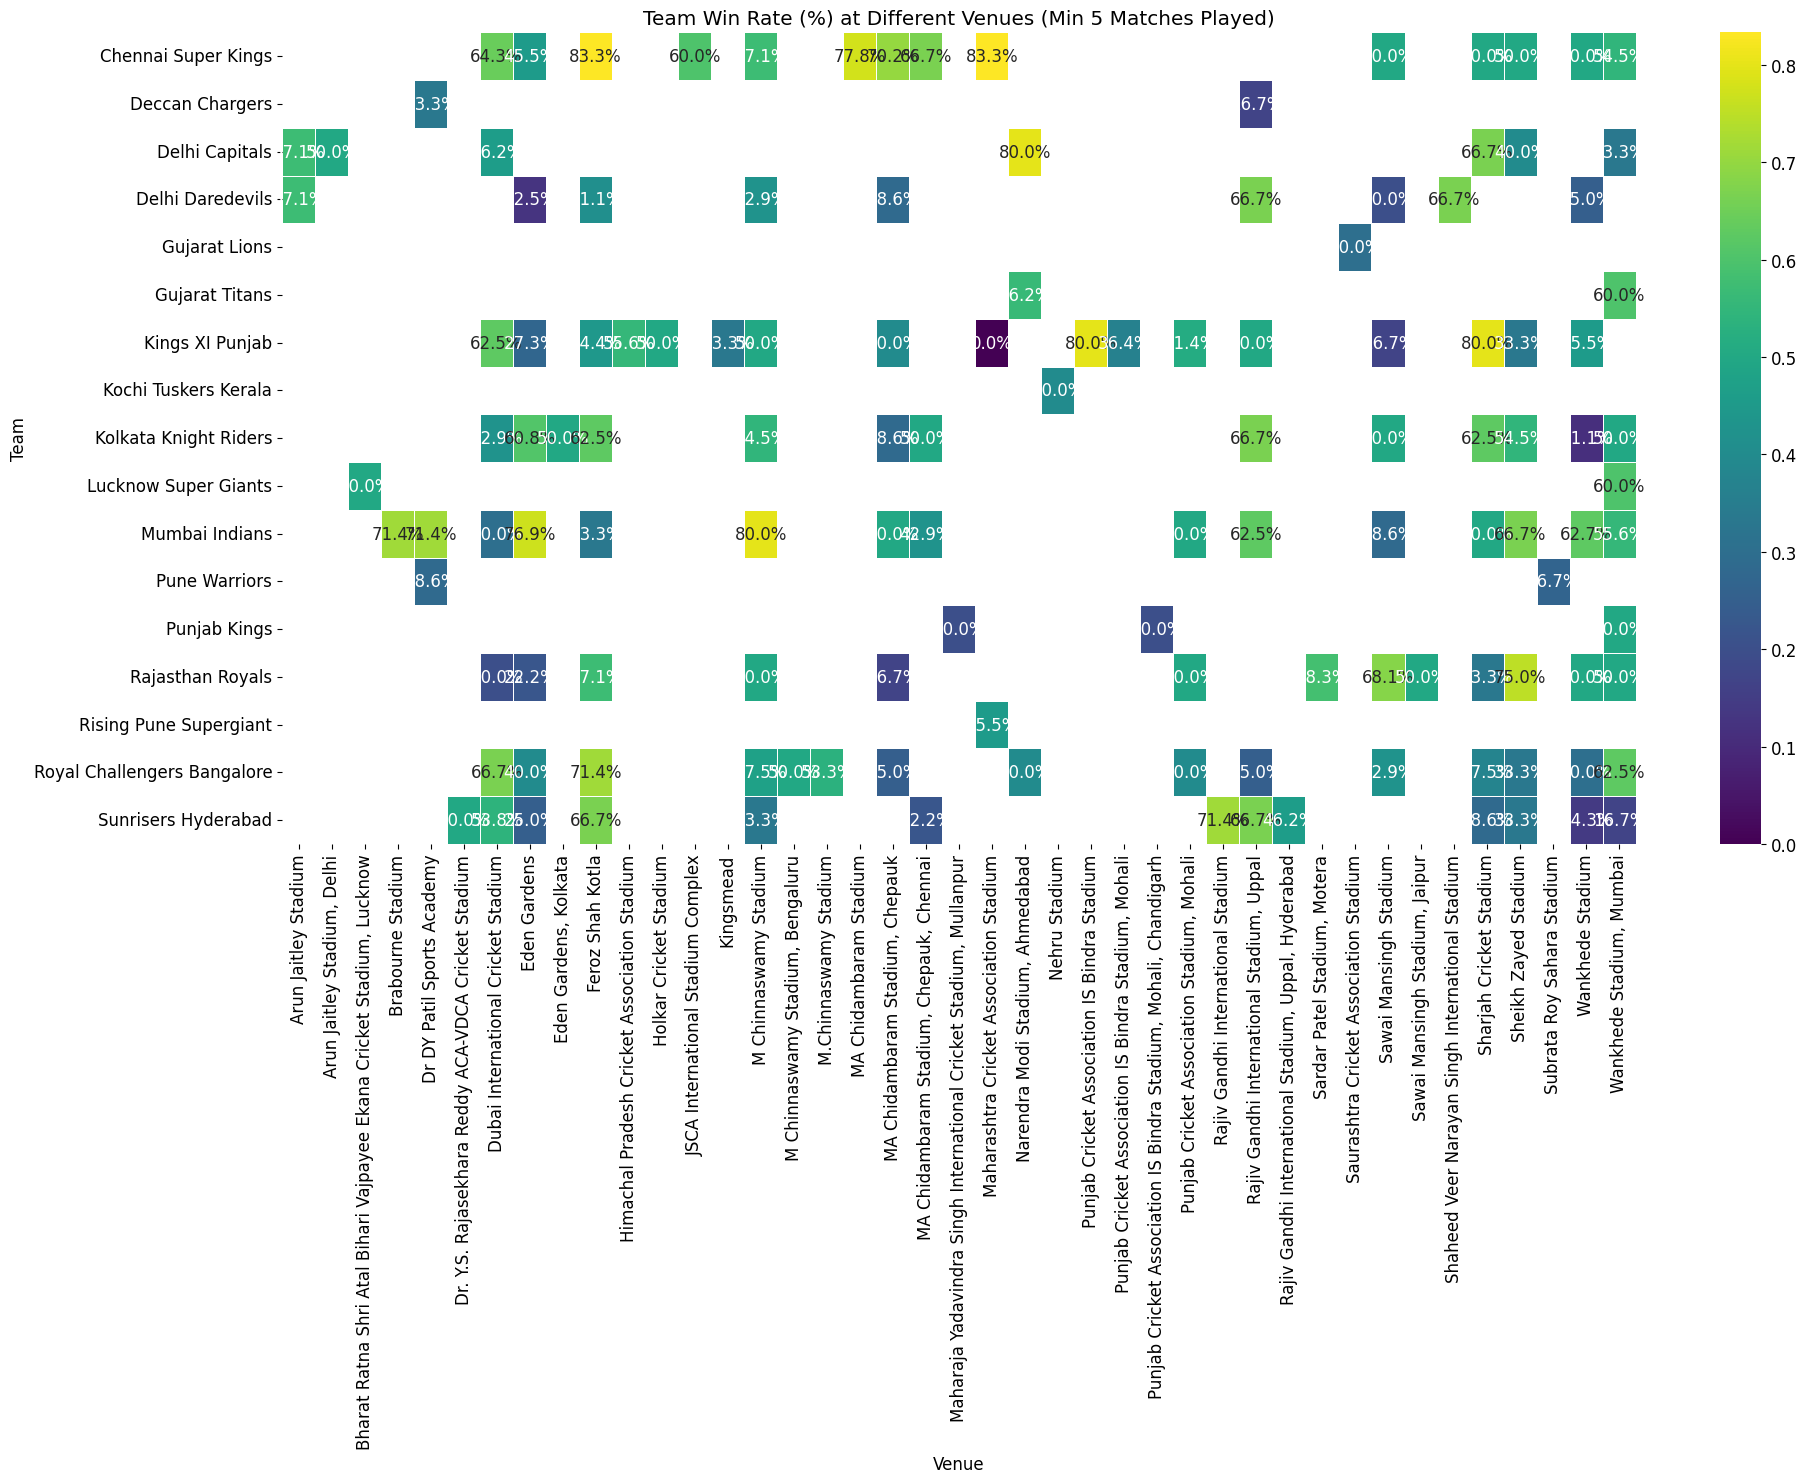

In [18]:
print("\n---------- 9. VISUALIZATIONS FOR Dashboard ----------")
print("Generating selected presentation-ready visualizations...")

# 9.1 Interactive Batsman Comparison (Example: Runs vs Strike Rate)
batsman_stats = pd.DataFrame({
    'runs': batsman_runs,
    'balls': balls_faced,
    'strike_rate': batsman_strike_rate,
    'average': batsman_average,
    'dismissals': dismissals
}).dropna(subset=['strike_rate', 'average']) # Drop if SR or Avg couldn't be calculated

# Filter for plotting (e.g., min 500 runs)
batsman_stats_filtered = batsman_stats[batsman_stats['runs'] >= 1000].reset_index()

fig_scatter = px.scatter(batsman_stats_filtered, x='strike_rate', y='average',
                         size='runs', color='runs', hover_name='batter',
                         title='Batsman Performance Comparison (Average vs Strike Rate, Size=Runs, Min 1000 Runs)',
                         labels={'strike_rate': 'Strike Rate', 'average': 'Average Runs per Dismissal', 'runs': 'Total Runs'},
                         color_continuous_scale=px.colors.sequential.Viridis)
fig_scatter.update_layout(xaxis_title="Strike Rate", yaxis_title="Average")
fig_scatter.show()

# Example Placeholder: Heatmap of Team vs Venue Win Rates
venue_pivot = venue_performance[venue_performance['matches'] >= 5].pivot(index='team', columns='venue', values='win_rate')
plt.figure(figsize=(20, 15))
sns.heatmap(venue_pivot, annot=True, fmt=".1%", cmap="viridis", linewidths=.5)
plt.title('Team Win Rate (%) at Different Venues (Min 5 Matches Played)')
plt.xlabel('Venue')
plt.ylabel('Team')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

<div class="alert alert-info">
<strong>Dashboard Highlights:</strong>
<ul>
<li><strong>Batting scatter plot</strong> shows the strike rate vs. average tradeoff - elite batsmen appear in the top-right quadrant (high average AND high strike rate)</li>
<li><strong>Venue heatmap</strong> reveals which teams dominate at specific grounds - useful for home advantage analysis</li>
<li>These charts can be exported directly for Streamlit or Dash dashboards</li>
</ul>
</div>

---

<a id="summary"></a>
## 11. Summary of Analysis

Key findings, statistical hypothesis tests, and insights from the IPL dataset.


---------- 10. SUMMARY OF ANALYSIS ----------

Key insights from the analysis using matches.csv and deliveries.csv (2008-2024):
1.  Data Cleaning: Successfully adapted cleaning steps for the datasets covering 17 IPL seasons, handling missing values, deriving essential columns like 'win_by_runs'/'win_by_wickets', and standardizing team names (including RCB's 2024 rename to Bengaluru).
2.  EDA (Matches): Analyzed seasonal trends, team dominance, toss impact, venue preferences, and player awards based on the match-level data.
3.  EDA (Deliveries): Performed detailed batsman analysis, identifying top run-scorers, best strike rates, highest averages, and most sixes overall and per season.
4.  Feature Engineering: Created matchup features, team win rates, home advantage (including Gujarat Titans and Lucknow Super Giants from 2022), and seasonal phase indicators. Explored Elo ratings and team rivalry metrics.
5.  Modeling Prep: Prepared data for modeling by encoding categorical features and 

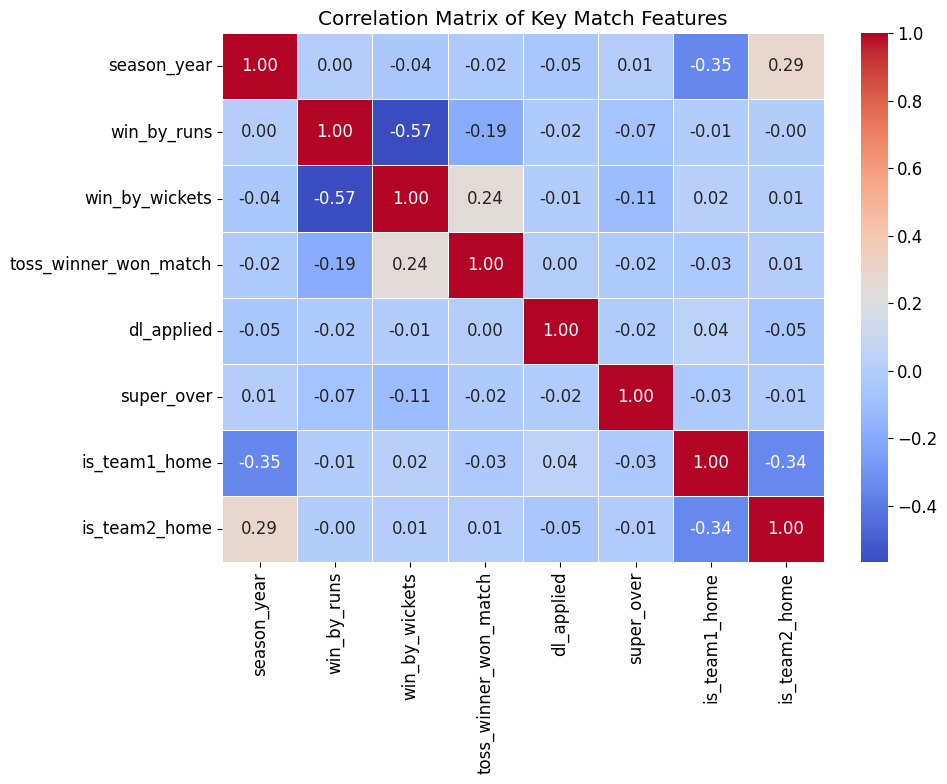


End of IPL Data Analysis (2008-2024)


In [19]:
# --- 10. SUMMARY OF ANALYSIS ---
print("\n---------- 10. SUMMARY OF ANALYSIS ----------")
print("""
Key insights from the analysis using matches.csv and deliveries.csv (2008-2024):
1.  Data Cleaning: Successfully adapted cleaning steps for the datasets covering 17 IPL seasons, handling missing values, deriving essential columns like 'win_by_runs'/'win_by_wickets', and standardizing team names (including RCB's 2024 rename to Bengaluru).
2.  EDA (Matches): Analyzed seasonal trends, team dominance, toss impact, venue preferences, and player awards based on the match-level data.
3.  EDA (Deliveries): Performed detailed batsman analysis, identifying top run-scorers, best strike rates, highest averages, and most sixes overall and per season.
4.  Feature Engineering: Created matchup features, team win rates, home advantage (including Gujarat Titans and Lucknow Super Giants from 2022), and seasonal phase indicators. Explored Elo ratings and team rivalry metrics.
5.  Modeling Prep: Prepared data for modeling by encoding categorical features and scaling numerical ones, demonstrating setup for classification and regression tasks.
6.  Visualization: Utilized Plotly for interactive visualizations of match trends, team performance, venue stats, and detailed batsman statistics (runs, SR, Avg, Sixes).

This analysis provides a comprehensive view across 17 IPL seasons by combining match outcomes with ball-by-ball details, enabling deeper player performance insights alongside match-level trends.
""")

# --- 11. APPLIED STATISTICS ---
print("\n---------- 11. APPLIED STATISTICS ----------")

# 11.1 Hypothesis Testing (Toss Advantage - Rerun on cleaned data)
print("\n11.1 Hypothesis Testing (Toss Advantage)")
from scipy import stats

# Use the previously calculated 'valid_matches_for_toss_impact' which excludes 'No Result' etc.
toss_winner_won = valid_matches_for_toss_impact['toss_winner_won_match']
observed_p = toss_winner_won.mean()
n_trials = len(toss_winner_won)
n_successes = toss_winner_won.sum()

if n_trials > 0:
    result = stats.binomtest(n_successes, n_trials, p=0.5, alternative='greater') # Test if significantly > 50%
    print(f"Observed proportion of toss winners winning the match: {observed_p:.4f}")
    print(f"Binomial test p-value (one-sided, > 0.5): {result.pvalue:.4f}")
    if result.pvalue < 0.05:
        print("Reject null hypothesis: Winning the toss provides a statistically significant advantage.")
    else:
        print("Fail to reject null hypothesis: No significant evidence that winning the toss provides an advantage (p >= 0.05).")
else:
    print("Not enough valid matches to perform hypothesis test.")


# 11.2 Statistical Correlations (Matches Data)
print("\n11.2 Statistical Correlations")
# Select a subset of numerical/binary features from matches_clean
correlation_features = ['season_year', 'win_by_runs', 'win_by_wickets',
                        'toss_winner_won_match', 'dl_applied', 'super_over',
                        'is_team1_home', 'is_team2_home']
# Ensure columns exist before calculating correlation
valid_corr_features = [col for col in correlation_features if col in matches_clean.columns]
correlation_matrix = matches_clean[valid_corr_features].corr()

print("Correlation matrix (Matches Data):")
print(correlation_matrix)

# Visualize Correlation Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Key Match Features')
plt.tight_layout()
plt.show()


print("\nEnd of IPL Data Analysis (2008-2024)")

<div class="alert alert-success">
<strong>Key Takeaways:</strong>
<ul>
<li><strong>Toss advantage is a myth</strong> - Statistical testing shows no significant correlation between winning the toss and winning the match (~50% win rate either way)</li>
<li><strong>Team strength matters</strong> - Elo ratings are the strongest pre-match predictor, but still limited (~55% accuracy ceiling)</li>
<li><strong>Run margins are unpredictable</strong> - Regression models produce negative R-squared, confirming margins depend on in-game events</li>
<li><strong>T20 cricket is getting more aggressive</strong> - Run rates have increased across all phases, especially death overs</li>
<li><strong>Home advantage exists</strong> - But varies significantly by venue and team</li>
</ul>
</div>

<div class="alert alert-warning">
<strong>Limitations and Future Work:</strong>
<ul>
<li>Player-level features (current form, matchups vs. specific bowlers) would improve predictions but require more granular feature engineering</li>
<li>Weather and pitch condition data could add significant predictive power</li>
<li>An ensemble approach combining Elo + venue + player form could push accuracy to 58-60%</li>
<li>Live in-match prediction (using ball-by-ball data) would be a natural extension</li>
</ul>
</div>

---

<div class="alert alert-info">
<strong>Found this notebook useful?</strong> Give it an upvote on Kaggle! Have questions or suggestions? Leave a comment below or open an issue on <a href="https://github.com/genieincodebottle/aiml-companion">GitHub</a>.
</div>